# TidalPy performance trends

This notebook loads every run recorded under `results/` and shows how each task's timing has moved
across the axes the harness records: **run date**, **TidalPy version**, and **machine / OS**. Run the
suite first with `python run_all.py` (from this directory) so there is data to plot, then rerun it
after changes and this notebook shows the difference.

Run it from this directory so `import harness` resolves and the installed TidalPy is used.


In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

import harness

df = harness.load_results_df()
print(f"{len(df)} task-rows across {df['source_file'].nunique()} run(s)")
df[["name", "tidalpy_version", "os", "node"]].drop_duplicates().reset_index(drop=True)


9 task-rows across 1 run(s)


,name,tidalpy_version,os,node
0,build_world:earth_simple,0.8.0a1.dev2,Windows,JoeDesktop
1,build_world:jupiter_simple,0.8.0a1.dev2,Windows,JoeDesktop
2,build_world:earth_prem,0.8.0a1.dev2,Windows,JoeDesktop
3,build_system:sol_system,0.8.0a1.dev2,Windows,JoeDesktop
4,solve_eos:earth_prem,0.8.0a1.dev2,Windows,JoeDesktop
5,tidal_heating:fixed_q,0.8.0a1.dev2,Windows,JoeDesktop
6,love_numbers:radial_solver,0.8.0a1.dev2,Windows,JoeDesktop
7,rheology:complex_modulus,0.8.0a1.dev2,Windows,JoeDesktop
8,system_evolution:fixed_q,0.8.0a1.dev2,Windows,JoeDesktop


## Most recent run
The per-call minimum, median, and standard deviation of every task in the newest run, with the environment it ran in.

In [2]:
latest_file = df.sort_values("timestamp_utc")["source_file"].iloc[-1]
latest = df[df["source_file"] == latest_file]
env = latest.iloc[0]
print(f"run     : {latest_file}")
print(f"version : {env['tidalpy_version']}  commit {env['git_commit']}")
print(f"machine : {env['os']} {env['os_release']} / {env['node']} ({env['processor']})")
latest.set_index("name")[["min_ms", "median_ms", "stdev_ms", "number", "repeats"]].round(4)


run     : 20260815T021848_0000_JoeDesktop_0.8.0a1.dev2.json
version : 0.8.0a1.dev2  commit a928609
machine : Windows 11 / JoeDesktop (AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD)


,min_ms,median_ms,stdev_ms,number,repeats
name,,,,,
build_world:earth_simple,0.9977,1.0261,0.0255,200,7
build_world:jupiter_simple,0.7614,0.7978,0.0291,500,7
build_world:earth_prem,1.9970,2.3014,0.1849,100,7
build_system:sol_system,3.3183,3.4148,0.0995,100,7
solve_eos:earth_prem,12.9921,13.7720,0.6610,20,7
tidal_heating:fixed_q,0.0058,0.0061,0.0003,50000,7
love_numbers:radial_solver,0.2437,0.3251,0.0408,1000,7
rheology:complex_modulus,0.0001,0.0002,0.0000,100000,7
system_evolution:fixed_q,0.0076,0.0084,0.0011,50000,7


## Timing over time
Per-call minimum time for each task against the run date. A step up is a regression, a step down a speedup. The axis is logarithmic so tasks at very different scales share the plot.

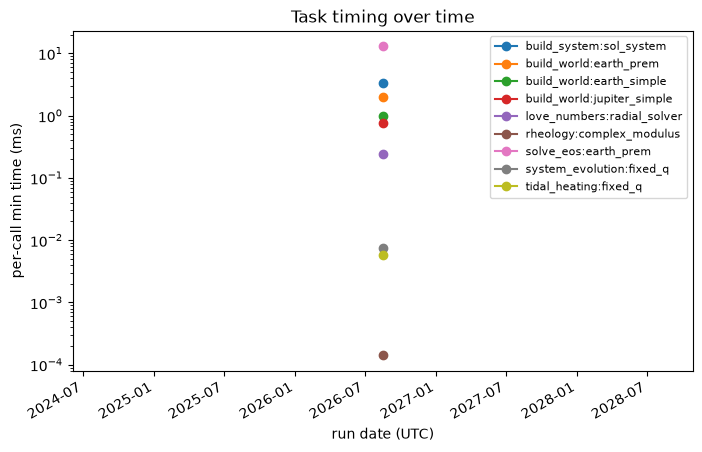

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, g in df.sort_values("timestamp_utc").groupby("name"):
    ax.plot(g["timestamp_utc"], g["min_ms"], marker="o", label=name)
ax.set_xlabel("run date (UTC)")
ax.set_ylabel("per-call min time (ms)")
ax.set_yscale("log")
ax.set_title("Task timing over time")
ax.legend(fontsize=8, loc="best")
fig.autofmt_xdate()
plt.show()


## Timing by TidalPy version
For each task, the latest recorded time under each TidalPy version, so version-to-version changes are directly comparable.

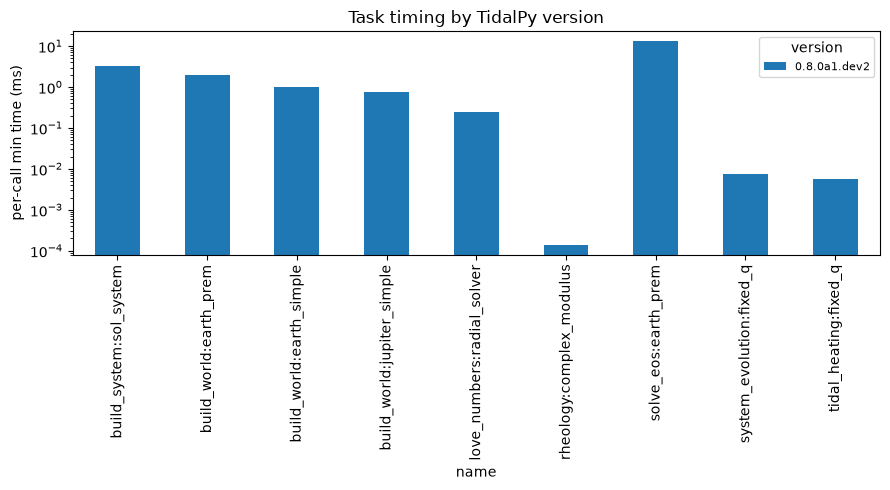

tidalpy_version,0.8.0a1.dev2
name,
build_system:sol_system,3.3183
build_world:earth_prem,1.9970
build_world:earth_simple,0.9977
build_world:jupiter_simple,0.7614
love_numbers:radial_solver,0.2437
rheology:complex_modulus,0.0001
solve_eos:earth_prem,12.9921
system_evolution:fixed_q,0.0076
tidal_heating:fixed_q,0.0058


In [4]:
by_version = (
    df.sort_values("timestamp_utc")
    .groupby(["name", "tidalpy_version"], as_index=False)
    .last()
    .pivot(index="name", columns="tidalpy_version", values="min_ms")
)
ax = by_version.plot.bar(figsize=(9, 5), logy=True)
ax.set_ylabel("per-call min time (ms)")
ax.set_title("Task timing by TidalPy version")
ax.legend(title="version", fontsize=8)
plt.tight_layout()
plt.show()
by_version.round(4)


## Timing by machine
The latest time for each task on each machine, for comparing across OS and hardware as more machines report in.

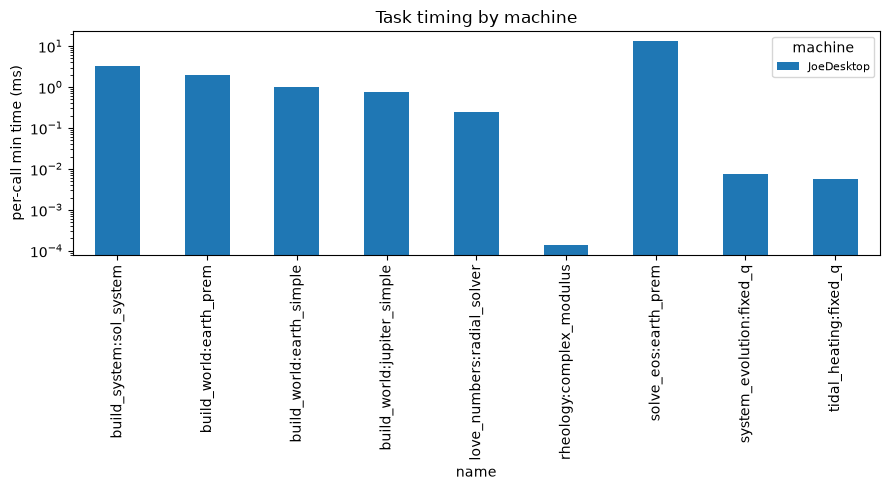

node,JoeDesktop
name,
build_system:sol_system,3.3183
build_world:earth_prem,1.9970
build_world:earth_simple,0.9977
build_world:jupiter_simple,0.7614
love_numbers:radial_solver,0.2437
rheology:complex_modulus,0.0001
solve_eos:earth_prem,12.9921
system_evolution:fixed_q,0.0076
tidal_heating:fixed_q,0.0058


In [5]:
by_node = (
    df.sort_values("timestamp_utc")
    .groupby(["name", "node"], as_index=False)
    .last()
    .pivot(index="name", columns="node", values="min_ms")
)
ax = by_node.plot.bar(figsize=(9, 5), logy=True)
ax.set_ylabel("per-call min time (ms)")
ax.set_title("Task timing by machine")
ax.legend(title="machine", fontsize=8)
plt.tight_layout()
plt.show()
by_node.round(4)
